# Laptop Analysis

## Load and Inspect the Dataset

First, I will load the dataset and check its basic structure.

In [61]:
import pandas as pd

In [62]:
df = pd.read_csv('./data/laptops.csv')
df

,Title,Price,Image URL,Specifications
0,"Laptop HP OmniBook 3 16-by0028nwx 16"" R5 40 8G...",1 999.00 zł,https://f00.esfr.pl/foto/4/192315626929/e8ea62...,"{'Ekran': '16 "", 1920 x 1200 pikseli', 'Proce..."
1,"Laptop gamingowy Lenovo LOQ 15IAX9 15,6"" 144Hz...",3 499.00 zł,https://f00.esfr.pl/foto/7/177142838209/75780b...,"{'Ekran': '15,6 "", 1920 x 1080 pikseli 144 Hz..."
2,Laptop gamingowy Dell Alienware 16 Aurora AC16...,3 299.00 zł,https://f00.esfr.pl/foto/2/188164628089/f7bd6d...,"{'Ekran': '16 "", 2560 x 1600 pikseli 120 Hz',..."
3,Laptop gamingowy ASUS TUF Gaming F16 FX607VJB-...,3 299.00 zł,https://f00.esfr.pl/foto/4/191218243201/6365f8...,"{'Ekran': '16 "", 1920 x 1200 pikseli 144 Hz',..."
4,"Laptop Lenovo IdeaPad Slim 3 16ARP10 16"" R5 75...",2 699.00 zł,https://f00.esfr.pl/foto/4/187619326041/eed87c...,"{'Ekran': '16 "", 1920 x 1200 pikseli 60 Hz', ..."
...,...,...,...,...
1070,"Laptop biznesowy HP 470 G9 17,3"" i7-1255U 16GB...",NaN,https://f00.esfr.pl/foto/9/120043513681/2a841f...,"{'Ekran': '17,3 "", 1920 x 1080 pikseli', 'Pro..."
1071,Laptop ASUS Vivobook 16 Flip TP3607SH-RJ007W O...,NaN,https://f00.esfr.pl/foto/7/172240043369/f2f3fe...,"{'Ekran': '16 "", ekran dotykowy 2880 x 1800 pi..."
1072,Laptop biznesowy ASUS ExpertBook B9 OLED B9403...,NaN,https://f00.esfr.pl/foto/8/184604732593/2dc278...,"{'Ekran': '14 "", 2880 x 1800 pikseli 120 Hz',..."
1073,Laptop gamingowy HP OMEN 16-u0042nw 16'' 240Hz...,NaN,https://f00.esfr.pl/foto/2/137623950793/656345...,"{'Ekran': '16 "", 2560 x 1600 pikseli 240 Hz',..."


### Dataset Shape

Let's check the number of rows and columns.

In [63]:
df.shape

(1075, 4)

### Column Names

Let's check the column names.

In [64]:
df.columns

Index(['Title', 'Price', 'Image URL', 'Specifications'], dtype='object')

### Data Types

Let's check the data types and the structure of the dataset.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Title           1075 non-null   object
 1   Price           842 non-null    object
 2   Image URL       1075 non-null   object
 3   Specifications  1075 non-null   object
dtypes: object(4)
memory usage: 33.7+ KB


### Missing Values

Let's check for missing values in each column.

In [66]:
df.isna().sum()

Title               0
Price             233
Image URL           0
Specifications      0
dtype: int64

### Duplicate Rows

Let's check for duplicate rows.

In [67]:
df.duplicated().sum()

0

### Basic Statistics

Let's look at some basic statistics.

In [68]:
df.describe(include="all").T

,count,unique,top,freq
Title,1075,1057,"Laptop biznesowy Dell Pro 16 Plus PB16250 16"" ...",3
Price,842,265,2 999.00 zł,26
Image URL,1075,1075,https://f00.esfr.pl/foto/4/192315626929/e8ea62...,1
Specifications,1075,914,"{'Ekran': '15,3"", 2880 x 1864 pikseli', 'Proc...",8


### Initial Observations

The dataset contains 1,075 laptop records and 4 columns.

There are 233 missing prices and no fully duplicated rows.

The columns are stored as an `object` type.

## Data Cleaning

### Clean Price

The `Price` column contains prices as text. I will convert it to a numeric type.

In [69]:
df['Price'].values

array(['1 999.00 zł', '3 499.00 zł', '3 299.00 zł', ..., nan, nan, nan],
      dtype=object)

In [70]:
df['Price'] = df['Price'].str.replace('zł', '').str.replace(' ', '').astype(float)
df['Price']

0       1999.0
1       3499.0
2       3299.0
3       3299.0
4       2699.0
         ...  
1070       NaN
1071       NaN
1072       NaN
1073       NaN
1074       NaN
Name: Price, Length: 1075, dtype: float64

In [71]:
df['Price'].agg(['mean', 'median', 'min', 'max'])

mean       6219.193147
median     4999.000000
min        1299.000000
max       27999.000000
Name: Price, dtype: float64

### Check Repeated Titles

Let's check if some laptop titles appear more than once.

In [72]:
duplicates = df[df['Title'].duplicated(keep=False)].sort_values('Title')
duplicates

,Title,Price,Image URL,Specifications
43,Laptop 2w1 Lenovo Yoga 7 2-in-1 14AKP10 OLED 1...,4399.00,https://f00.esfr.pl/foto/9/183197190761/c955e7...,"{'Ekran': '14 "", ekran dotykowy 1920 x 1200 pi..."
662,Laptop 2w1 Lenovo Yoga 7 2-in-1 14AKP10 OLED 1...,4699.00,https://f00.esfr.pl/foto/7/165847215945/c955e7...,"{'Ekran': '14 "", ekran dotykowy 1920 x 1200 pi..."
569,"Laptop Acer Nitro V 16 ANV16-41 16"" 165Hz R5 8...",2999.00,https://f00.esfr.pl/foto/1/150516397337/1487b5...,"{'Ekran': '16 "", 1920 x 1200 pikseli 165 Hz',..."
554,"Laptop Acer Nitro V 16 ANV16-41 16"" 165Hz R5 8...",2999.00,https://f00.esfr.pl/foto/4/171675935001/1487b5...,"{'Ekran': '16 "", 1920 x 1200 pikseli 165 Hz',..."
30,"Laptop Acer Nitro V 16 ANV16-41 16"" 165Hz R5 8...",3999.00,https://f00.esfr.pl/foto/5/171675903889/4b3b6b...,"{'Ekran': '16 "", 1920 x 1200 pikseli 165 Hz',..."
457,"Laptop Acer Nitro V 16 ANV16-41 16"" 165Hz R5 8...",4399.00,https://f00.esfr.pl/foto/7/153880298161/63e252...,"{'Ekran': '16 "", 1920 x 1200 pikseli 165 Hz',..."
557,"Laptop Lenovo Yoga Slim 7 14AKP10 OLED 14"" Ryz...",4299.00,https://f00.esfr.pl/foto/4/165847139385/746959...,"{'Ekran': '14 "", 1920 x 1200 pikseli 60 Hz', ..."
516,"Laptop Lenovo Yoga Slim 7 14AKP10 OLED 14"" Ryz...",3699.00,https://f00.esfr.pl/foto/7/183197104097/746959...,"{'Ekran': '14 "", 1920 x 1200 pikseli 60 Hz', ..."
501,"Laptop biznesowy Dell Pro 13 Plus PB13250 13,3...",7949.00,https://f00.esfr.pl/foto/3/183280620689/67271d...,"{'Ekran': '13,3 "", ekran dotykowy 1920 x 1200 ..."
488,"Laptop biznesowy Dell Pro 13 Plus PB13250 13,3...",7599.00,https://f00.esfr.pl/foto/8/183280509841/67271d...,"{'Ekran': '13,3 "", 1920 x 1200 pikseli 60 Hz'..."


### Specifications

Let's check the data type and some values from the `Specifications` column.

In [73]:
df["Specifications"].dtype

dtype('O')

In [74]:
df["Specifications"].head()

0    {'Ekran': '16 ",  1920 x 1200 pikseli', 'Proce...
1    {'Ekran': '15,6 ",  1920 x 1080 pikseli 144 Hz...
2    {'Ekran': '16 ",  2560 x 1600 pikseli 120 Hz',...
3    {'Ekran': '16 ",  1920 x 1200 pikseli 144 Hz',...
4    {'Ekran': '16 ",  1920 x 1200 pikseli 60 Hz', ...
Name: Specifications, dtype: object

### Laptops Without Price

Let's look at laptops where the price is missing.

In [75]:
df_no_price = df[df['Price'].isna()]
df_no_price.head(10)

,Title,Price,Image URL,Specifications
842,Laptop gamingowy Lenovo Legion Pro 5 16IAX10 O...,NaN,https://f00.esfr.pl/foto/6/187619370057/144499...,"{'Ekran': '16 "", 2560 x 1600 pikseli 165 Hz',..."
843,Laptop gamingowy Gigabyte Gaming A16 3THK3EE89...,NaN,https://f00.esfr.pl/foto/6/173811870289/f5110a...,"{'Ekran': '16 "", 1920 x 1200 pikseli 165 Hz',..."
844,Laptop 2w1 HP OmniBook Ultra Flip 14-fh0216nw ...,NaN,https://f00.esfr.pl/foto/3/184148947905/cfd7ff...,"{'Ekran': '14 "", ekran dotykowy 2880 x 1800 pi..."
845,Laptop gamingowy MSI Titan 18 HX Dragon Editio...,NaN,https://f00.esfr.pl/foto/7/192277966257/974670...,"{'Ekran': '18 "", 3840 x 2400 pikseli 240 Hz',..."
846,"Laptop gamingowy HP Victus 15-fb3078nw 15,6"" 1...",NaN,https://f00.esfr.pl/foto/5/184148874433/93b35a...,"{'Ekran': '15,6 "", 1920 x 1080 pikseli 144 Hz..."
847,"Apple MacBook Air 2025 15,3"" M4 16GB RAM 512GB...",NaN,https://f00.esfr.pl/foto/5/165147977201/1cydbu...,"{'Ekran': '15,3"", 2880 x 1864 pikseli', 'Proc..."
848,Laptop gamingowy Gigabyte Gaming A18 3VHK3EEF9...,NaN,https://f00.esfr.pl/foto/1/173812021065/4ba17a...,"{'Ekran': '18 "", 1920 x 1200 pikseli 165 Hz',..."
849,"Apple MacBook Air 2025 15,3"" M4 16GB RAM 512GB...",NaN,https://f00.esfr.pl/foto/9/165147820657/4tivv8...,"{'Ekran': '15,3"", 2880 x 1864 pikseli', 'Proc..."
850,"Apple MacBook Air 2025 15,3"" M4 24GB RAM 512GB...",NaN,https://f00.esfr.pl/foto/7/165147723473/1dv93f...,"{'Ekran': '15,3"", 2880 x 1864 pikseli', 'Proc..."
851,"Apple MacBook Air 2025 13,6"" M4 24GB RAM 512GB...",NaN,https://f00.esfr.pl/foto/2/159937723345/10qx7y...,"{'Ekran': '13,6 "", 2560 x 1664 pikseli', 'Pro..."


### Final Check

Let's check the final dataset after the price conversion.

In [76]:
df.shape

(1075, 4)

In [77]:
df["Price"].dtype

dtype('float64')

In [78]:
df["Price"].isna().sum()

233

In [79]:
df.duplicated().sum()

0

### Laptops With Known Prices

I will create a separate DataFrame for laptops with known prices.
I will keep the original DataFrame unchanged.

In [80]:
df_price = df.dropna(subset=["Price"])

In [81]:
df_price.shape

(842, 4)

In [82]:
df_price["Price"].isna().sum()

0

In [83]:
df.shape

(1075, 4)

### Final Check

After cleaning the price column:

The dataset still contains 1,075 rows.

The `Price` column is `float64`.

There are 233 missing prices.

There are no fully duplicated rows.

The `df_price` DataFrame contains only laptops with a known price.

Some laptop titles appear more than once, so I will check these records later.

The `Specifications` column has an `object` data type and contains laptop specifications.

## Parse Specifications

The `Specifications` column is stored as a string.

Each value contains a dictionary with laptop specifications. I will convert these strings into Python dictionaries and then create separate columns.

In [84]:
type(df["Specifications"].iloc[0])

str

In [85]:
df["Specifications"].iloc[0]

'{\'Ekran\': \'16 ",  1920 x 1200 pikseli\', \'Procesor\': \'AMD Ryzen™ 5 40\', \'Pamięć\': \'8 GB  LPDDR5 5500 Mhz RAM\', \'Grafika\': \'AMD  Radeon™ 610M Graphics\', \'Dysk\': \'256 GB SSD\', \'System operacyjny\': \'Windows 11 Home Edition\'}'

The values are stored as strings, so I will convert them into Python dictionaries.

In [86]:
import ast

In [87]:
df["Specifications"] = df["Specifications"].apply(ast.literal_eval)
df["Specifications"]

0       {'Ekran': '16 ",  1920 x 1200 pikseli', 'Proce...
1       {'Ekran': '15,6 ",  1920 x 1080 pikseli 144 Hz...
2       {'Ekran': '16 ",  2560 x 1600 pikseli 120 Hz',...
3       {'Ekran': '16 ",  1920 x 1200 pikseli 144 Hz',...
4       {'Ekran': '16 ",  1920 x 1200 pikseli 60 Hz', ...
                              ...                        
1070    {'Ekran': '17,3 ",  1920 x 1080 pikseli', 'Pro...
1071    {'Ekran': '16 ", ekran dotykowy 2880 x 1800 pi...
1072    {'Ekran': '14 ",  2880 x 1800 pikseli 120 Hz',...
1073    {'Ekran': '16 ",  2560 x 1600 pikseli 240 Hz',...
1074    {'Ekran': '13,5 ", ekran dotykowy 1920 x 1280 ...
Name: Specifications, Length: 1075, dtype: object

In [88]:
type(df["Specifications"].iloc[0])

dict

The `Specifications` values are now Python dictionaries.

I will use `json_normalize()` to expand the dictionaries into separate columns.

In [89]:
specs = pd.json_normalize(df["Specifications"])

df = pd.concat([df, specs], axis=1)

I will rename the columns to make them easier to work with.

In [90]:
df = df.rename(columns={
    "Ekran": "screen",
    "Procesor": "processor",
    "Pamięć": "ram",
    "Grafika": "graphics",
    "Dysk": "storage",
    "System operacyjny": "os"
})

In [91]:
df.head(5)

,Title,Price,Image URL,Specifications,screen,processor,ram,graphics,storage,os
0,"Laptop HP OmniBook 3 16-by0028nwx 16"" R5 40 8G...",1999.0,https://f00.esfr.pl/foto/4/192315626929/e8ea62...,"{'Ekran': '16 "", 1920 x 1200 pikseli', 'Proce...","16 "", 1920 x 1200 pikseli",AMD Ryzen™ 5 40,8 GB LPDDR5 5500 Mhz RAM,AMD Radeon™ 610M Graphics,256 GB SSD,Windows 11 Home Edition
1,"Laptop gamingowy Lenovo LOQ 15IAX9 15,6"" 144Hz...",3499.0,https://f00.esfr.pl/foto/7/177142838209/75780b...,"{'Ekran': '15,6 "", 1920 x 1080 pikseli 144 Hz...","15,6 "", 1920 x 1080 pikseli 144 Hz",Intel® Core™ i5 12gen 12600HX,16 GB DDR5 4800 Mhz RAM,NVIDIA® GeForce RTX™ 4050 + Intel UHD Graphics,512 GB SSD,Windows 11 Home Edition
2,Laptop gamingowy Dell Alienware 16 Aurora AC16...,3299.0,https://f00.esfr.pl/foto/2/188164628089/f7bd6d...,"{'Ekran': '16 "", 2560 x 1600 pikseli 120 Hz',...","16 "", 2560 x 1600 pikseli 120 Hz",Intel® Core™ 5 15gen 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
3,Laptop gamingowy ASUS TUF Gaming F16 FX607VJB-...,3299.0,https://f00.esfr.pl/foto/4/191218243201/6365f8...,"{'Ekran': '16 "", 1920 x 1200 pikseli 144 Hz',...","16 "", 1920 x 1200 pikseli 144 Hz",Intel® Core™ 5 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
4,"Laptop Lenovo IdeaPad Slim 3 16ARP10 16"" R5 75...",2699.0,https://f00.esfr.pl/foto/4/187619326041/eed87c...,"{'Ekran': '16 "", 1920 x 1200 pikseli 60 Hz', ...","16 "", 1920 x 1200 pikseli 60 Hz",AMD Ryzen™ 5 7535HS,24 GB DDR5 4800 Mhz RAM,AMD Radeon™ 660M Graphics,512 GB SSD,Windows 11 Home Edition


In [92]:
df = df[['Title', 'Price', 'Image URL', 'screen', 'processor', 'ram', 'graphics', 'storage', 'os']]

### Check the New Structure

The dataset now contains separate columns for the main laptop specifications.

In [93]:
df.head(5)

,Title,Price,Image URL,screen,processor,ram,graphics,storage,os
0,"Laptop HP OmniBook 3 16-by0028nwx 16"" R5 40 8G...",1999.0,https://f00.esfr.pl/foto/4/192315626929/e8ea62...,"16 "", 1920 x 1200 pikseli",AMD Ryzen™ 5 40,8 GB LPDDR5 5500 Mhz RAM,AMD Radeon™ 610M Graphics,256 GB SSD,Windows 11 Home Edition
1,"Laptop gamingowy Lenovo LOQ 15IAX9 15,6"" 144Hz...",3499.0,https://f00.esfr.pl/foto/7/177142838209/75780b...,"15,6 "", 1920 x 1080 pikseli 144 Hz",Intel® Core™ i5 12gen 12600HX,16 GB DDR5 4800 Mhz RAM,NVIDIA® GeForce RTX™ 4050 + Intel UHD Graphics,512 GB SSD,Windows 11 Home Edition
2,Laptop gamingowy Dell Alienware 16 Aurora AC16...,3299.0,https://f00.esfr.pl/foto/2/188164628089/f7bd6d...,"16 "", 2560 x 1600 pikseli 120 Hz",Intel® Core™ 5 15gen 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
3,Laptop gamingowy ASUS TUF Gaming F16 FX607VJB-...,3299.0,https://f00.esfr.pl/foto/4/191218243201/6365f8...,"16 "", 1920 x 1200 pikseli 144 Hz",Intel® Core™ 5 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
4,"Laptop Lenovo IdeaPad Slim 3 16ARP10 16"" R5 75...",2699.0,https://f00.esfr.pl/foto/4/187619326041/eed87c...,"16 "", 1920 x 1200 pikseli 60 Hz",AMD Ryzen™ 5 7535HS,24 GB DDR5 4800 Mhz RAM,AMD Radeon™ 660M Graphics,512 GB SSD,Windows 11 Home Edition


In [94]:
df.isna().sum()

Title          0
Price        233
Image URL      0
screen         0
processor      0
ram            0
graphics       0
storage        0
os             0
dtype: int64

In [95]:
df.shape

(1075, 9)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      1075 non-null   object 
 1   Price      842 non-null    float64
 2   Image URL  1075 non-null   object 
 3   screen     1075 non-null   object 
 4   processor  1075 non-null   object 
 5   ram        1075 non-null   object 
 6   graphics   1075 non-null   object 
 7   storage    1075 non-null   object 
 8   os         1075 non-null   object 
dtypes: float64(1), object(8)
memory usage: 75.7+ KB


### Result

The dataset now contains 1,075 rows and 9 columns.

The laptop specifications are stored in separate columns.

There are 233 missing prices, but the specification columns do not contain missing values.

The specification values are still stored as text. I will clean and extract useful numeric values in the next step.

## Clean Text Columns

In [97]:
cols = ['Title', 'screen', 'processor', 'ram', 'graphics', 'storage', 'os']

df[cols] = df[cols].apply(lambda col: col.str.strip())

In [98]:
(df[cols] == "").sum()

Title        0
screen       0
processor    0
ram          0
graphics     0
storage      0
os           0
dtype: int64

No empty strings (`""`) were found in the specification columns.

In [99]:
df[['os', 'ram', 'storage']].value_counts()

os                       ram                          storage   
Windows 11 Professional  16 GB  DDR5 5600 Mhz RAM     512 GB SSD    54
Windows 11 Home Edition  16 GB  DDR5 5600 Mhz RAM     512 GB SSD    48
                         16 GB  DDR4 3200 MHz RAM     512 GB SSD    45
                         16 GB  DDR5 RAM              512 GB SSD    42
                         16 GB  LPDDR5X RAM           512 GB SSD    27
                                                                    ..
Windows 11 Professional  16 GB  LPDDR5x 8000 Mhz RAM  1 TB SSD       1
Windows 11 Home Edition  24 GB  LPDDR5x 8533 Mhz RAM  512 GB SSD     1
Windows 11 Professional  16 GB  LPDDR5x 7467 Mhz RAM  512 GB SSD     1
                         16 GB  LPDDR5X RAM           512 GB SSD     1
Chrome OS                16 GB  LPDDR5X RAM           512 GB SSD     1
Name: count, Length: 249, dtype: int64

Check how often different combinations of operating system, RAM, and storage occur.

The results show 249 unique combinations. Some combinations are common, while others occur only once.

In [100]:
df.duplicated().sum()

0

In [101]:
df["Title"].duplicated().sum()

18

In [102]:
df.head()

,Title,Price,Image URL,screen,processor,ram,graphics,storage,os
0,"Laptop HP OmniBook 3 16-by0028nwx 16"" R5 40 8G...",1999.0,https://f00.esfr.pl/foto/4/192315626929/e8ea62...,"16 "", 1920 x 1200 pikseli",AMD Ryzen™ 5 40,8 GB LPDDR5 5500 Mhz RAM,AMD Radeon™ 610M Graphics,256 GB SSD,Windows 11 Home Edition
1,"Laptop gamingowy Lenovo LOQ 15IAX9 15,6"" 144Hz...",3499.0,https://f00.esfr.pl/foto/7/177142838209/75780b...,"15,6 "", 1920 x 1080 pikseli 144 Hz",Intel® Core™ i5 12gen 12600HX,16 GB DDR5 4800 Mhz RAM,NVIDIA® GeForce RTX™ 4050 + Intel UHD Graphics,512 GB SSD,Windows 11 Home Edition
2,Laptop gamingowy Dell Alienware 16 Aurora AC16...,3299.0,https://f00.esfr.pl/foto/2/188164628089/f7bd6d...,"16 "", 2560 x 1600 pikseli 120 Hz",Intel® Core™ 5 15gen 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
3,Laptop gamingowy ASUS TUF Gaming F16 FX607VJB-...,3299.0,https://f00.esfr.pl/foto/4/191218243201/6365f8...,"16 "", 1920 x 1200 pikseli 144 Hz",Intel® Core™ 5 210H,16 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 3050 + Intel Graphics,512 GB SSD,Windows 11 Home Edition
4,"Laptop Lenovo IdeaPad Slim 3 16ARP10 16"" R5 75...",2699.0,https://f00.esfr.pl/foto/4/187619326041/eed87c...,"16 "", 1920 x 1200 pikseli 60 Hz",AMD Ryzen™ 5 7535HS,24 GB DDR5 4800 Mhz RAM,AMD Radeon™ 660M Graphics,512 GB SSD,Windows 11 Home Edition


In [103]:
df.isna().sum()

Title          0
Price        233
Image URL      0
screen         0
processor      0
ram            0
graphics       0
storage        0
os             0
dtype: int64

In [104]:
df.shape

(1075, 9)

### Cleaning Notes

The text columns were cleaned by removing extra spaces.

There are no empty strings in the main text columns.

There are no fully duplicated rows.

There are 18 repeated laptop titles, but these rows will not be removed because the same laptop can have different prices or product data.

There are still 233 missing prices. These values will be kept for now.

## Exploratory Data Analysis

In [105]:
df.describe()

,Price
count,842.000000
mean,6219.193147
std,4058.497990
min,1299.000000
25%,3661.250000
50%,4999.000000
75%,7199.000000
max,27999.000000


In [106]:
df.sort_values("Price").head(10)

,Title,Price,Image URL,screen,processor,ram,graphics,storage,os
517,"Laptop biznesowy Dell Inspiron 3520-5807 15,6""...",1299.0,https://f00.esfr.pl/foto/4/131091161625/c5cff9...,"15,6 "", 1920 x 1080 pikseli 120 Hz",Intel® Core™ i5 12gen 1235U,8 GB DDR4 2666 MHz RAM,Intel® UHD Graphics 620,512 GB SSD,Windows 11 Professional
11,Laptop chromebook Lenovo IP Slim 3 Chrome 14M8...,1299.0,https://f00.esfr.pl/foto/5/154390152577/e34b4e...,"14 "", 1920 x 1080 pikseli 60 Hz",MediaTek™ Kompanio 520,8 GB LPDDR4X 3600 RAM,ARM® Mali G-52,128 GB SSD,Chrome OS
612,"Laptop Acer Aspire AL15-32P 15,6"" Celeron N450...",1379.0,https://f00.esfr.pl/foto/7/164159821521/bfcac0...,"15,6 "", 1920 x 1080 pikseli 60 Hz",Intel® Celeron® N4500,8 GB LPDDR4X RAM,Intel® UHD Graphics,256 GB SSD,bez systemu
545,Laptop Acer Chromebook Plus 515 Google AI lapt...,1399.0,https://f00.esfr.pl/foto/4/131046584113/1c46cd...,"15,6 "", 1920 x 1080 pikseli 60 Hz",Intel® Core™ i5 12gen 1235U,8 GB LPDDR5X RAM,Intel® Iris Xe Graphics,512 GB SSD,Chrome OS
588,"Laptop Dell Inspiron 3525-6518 15,6"" 120Hz R5 ...",1499.0,https://f00.esfr.pl/foto/2/100781798529/f977c6...,"15,6 "", 1920 x 1080 pikseli 120 Hz",AMD Ryzen™ 5 5625U,8 GB DDR4 3200 MHz RAM,AMD Radeon™ Graphics,512 GB SSD,Windows 11 Home Edition
705,"Laptop Acer Extensa 15 215-57 15,6"" i3-1315U 8...",1539.0,https://f00.esfr.pl/foto/1/183280663745/6d7503...,"15,6 "", 1920 x 1080 pikseli 60 Hz",Intel® Core™ i3 13gen 1315U,8 GB DDR5 4800 Mhz RAM,Intel® UHD Graphics,512 GB SSD,bez systemu
524,"Laptop HP ProBook 465 G11 16"" R5 7535U 16GB RA...",1599.0,https://f00.esfr.pl/foto/9/157219703169/124e6d...,"16 "", 1920 x 1200 pikseli",AMD Ryzen™ 5 7535U,16 GB DDR5 4800 Mhz RAM,AMD Radeon™ 660M,512 GB SSD,Windows 11 Home Edition
62,Laptop chromebook Acer Chromebook 315 CB315-6H...,1599.0,https://f00.esfr.pl/foto/4/187995797001/ada915...,"15,6 "", 1920 x 1080 pikseli 60 Hz",Intel® N150,8 GB LPDDR5X RAM,Intel® Graphics,128 GB SSD,Chrome OS
534,"Laptop 2w1 HP Envy x360 14-fa0222nw 14"" R5 864...",1699.0,https://f00.esfr.pl/foto/6/149667917185/e6edf9...,"14 "", ekran dotykowy 1920 x 1200 pikseli",AMD Ryzen™ 5 8640HS,16 GB LPDDR5 6400 Mhz RAM,AMD Radeon™ 760M,512 GB SSD,Windows 11 Home Edition
521,"Laptop ASUS Vivobook 16 X1605VA-MB1799W 16"" i5...",1799.0,https://f00.esfr.pl/foto/2/158146852033/c5e540...,"16 "", 1920 x 1200 pikseli 60 Hz",Intel® Core™ i5 13gen 13420H,16 GB DDR4 RAM,Intel® UHD Graphics,512 GB SSD,Windows 11 Home Edition


In [107]:
df.sort_values("Price", ascending=False).head(10)

,Title,Price,Image URL,screen,processor,ram,graphics,storage,os
338,Laptop ASUS ROG Zephyrus Duo 16 GX651AR-U9642X...,27999.00,https://f00.esfr.pl/foto/8/191218297497/6aa53f...,"16 "", ekran dotykowy 2880 x 1800 pikseli 120 Hz",Intel® Core™ Ultra 9 Series 3 386H,64 GB LPDDR5x 8533 Mhz RAM,NVIDIA® GeForce RTX™ 5070 Ti + Intel Graphics,2 TB SSD,Windows 11 Professional
758,Laptop gamingowy MSI Titan 18 HX AI A2XWJG-477...,26599.00,https://f00.esfr.pl/foto/2/168752069201/7dc71e...,"18 "", 3840 x 2400 pikseli 120 Hz",Intel® Core™ Ultra 9 15gen 285HX,64 GB DDR5 6400 Mhz RAM,NVIDIA® GeForce RTX™ 5090 + Intel Graphics,6 TB SSD,Windows 11 Professional
337,Laptop gamingowy MSI Titan 18 HX AI A2WJ-1234P...,25999.00,https://f00.esfr.pl/foto/7/192277934177/dc4ee7...,"18 "", 3840 x 2400 pikseli 240 Hz",Intel® Core™ Ultra 9 Series 2 290HX Plus,64 GB DDR5 6400 Mhz RAM,NVIDIA® GeForce RTX™ 5090 + Intel Graphics,2 TB SSD,Windows 11 Professional
311,"Apple MacBook Pro 2026 16,2"" M5 Max 18/40 48GB...",23999.00,https://f00.esfr.pl/foto/9/187428081705/786ce1...,"16,2 "", 3456 x 2234 pikseli 120 Hz",Apple M5 Max,48 GB zunifikowana RAM,Apple M5 Max (40-rdzeni),2 TB SSD,macOS
142,Laptop gamingowy ASUS ROG Zephyrus G16 GU606AX...,23364.99,https://f00.esfr.pl/foto/2/191218303857/b14bd7...,"16 "", 2560 x 1600 pikseli 240 Hz",Intel® Core™ Ultra 9 Series 3 386H,32 GB LPDDR5x 8533 Mhz RAM,NVIDIA® GeForce RTX™ 5090 + Intel Graphics,2 TB SSD,Windows 11 Professional
639,"Laptop gamingowy Lenovo Legion 9 18IAX10 18"" 2...",22499.00,https://f00.esfr.pl/foto/2/173301540337/ad0739...,"18 "", 3840 x 2400 pikseli 240 Hz",Intel® Core™ Ultra 9 15gen 275HX,64 GB DDR5 5200 Mhz RAM,NVIDIA® GeForce RTX™ 5090 + Intel Graphics,2 TB SSD,Windows 11 Professional
227,Laptop gamingowy MSI Titan 18 HX AI A2XWIG-220...,21999.00,https://f00.esfr.pl/foto/1/159341303945/7dc71e...,"18 "", 3840 x 2400 pikseli 120 Hz",Intel® Core™ Ultra 9 15gen 285HX,64 GB DDR5 6400 Mhz RAM,NVIDIA® GeForce RTX™ 5080 + Intel Graphics,6 TB SSD,Windows 11 Professional
264,Laptop gamingowy MSI Raider A18 HX A9WIG-072PL...,21999.00,https://f00.esfr.pl/foto/6/159341219425/623736...,"18 "", 3840 x 2400 pikseli 120 Hz",AMD Ryzen™ 9 9955HX3D,64 GB DDR5 5600 Mhz RAM,NVIDIA® GeForce RTX™ 5080 + AMD Radeon™ 610M,2 TB SSD,Windows 11 Home Edition
367,"Apple MacBook Pro 2026 16,2"" M5 Max 18/40 48GB...",21999.00,https://f00.esfr.pl/foto/2/187428632001/228348...,"16,2 "", 3456 x 2234 pikseli 120 Hz",Apple M5 Max,48 GB zunifikowana RAM,Apple M5 Max (40-rdzeni),2 TB SSD,macOS
732,Laptop gamingowy MSI Stealth 18 HX AI A2XWJG-0...,21599.00,https://f00.esfr.pl/foto/9/159341286969/ca966b...,"18 "", 3840 x 2400 pikseli 120 Hz",Intel® Core™ Ultra 9 15gen 275HX,64 GB DDR5 6400 Mhz RAM,NVIDIA® GeForce RTX™ 5090 + Intel Graphics,2 TB SSD,Windows 11 Professional


Let's compare the average laptop price across different RAM configurations.

In [108]:
df.groupby("ram")["Price"].mean().sort_values(ascending=False).head(10)

ram
64 GB  DDR5 6400 Mhz RAM       22749.000000
64 GB  DDR5 5200 Mhz RAM       22499.000000
64 GB  LPDDR5x 8533 Mhz RAM    19799.000000
48 GB  zunifikowana RAM        19199.000000
36 GB  zunifikowana RAM        19082.333333
64 GB  LPDDR5x 8400 Mhz RAM    17899.000000
64 GB  LPDDR5X RAM             17799.000000
64 GB  DDR5 5600 Mhz RAM       17468.198000
32 GB  LPDDR5 6000 Mhz RAM     17000.000000
32 GB  LPDDR5 5200 Mhz RAM     16287.000000
Name: Price, dtype: float64

The results show that laptops with larger RAM capacities tend to have higher average prices. However, RAM is not the only factor affecting the price, so this relationship should not be interpreted as a direct causal effect.

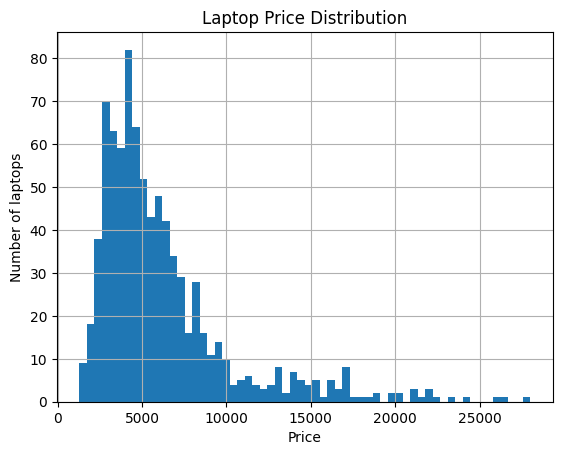

In [109]:
import matplotlib.pyplot as plt

df["Price"].hist(bins=60)

plt.xlabel("Price")
plt.ylabel("Number of laptops")
plt.title("Laptop Price Distribution")
plt.show()

### Exploratory Data Analysis

The average laptop price is 6219 PLN, while the median price is 4999 PLN.

The dataset contains laptops from 1299 PLN to 27999 PLN.

The price distribution is right skewed because a small number of expensive laptops increase the average price.

The most expensive laptops generally have high-end processors, more RAM, powerful graphics cards and larger storage.

### Price by Storage

Let's examine how storage capacity is distributed in the dataset and how it relates to laptop prices.

In [110]:
df["storage"].value_counts().head(15)

storage
512 GB SSD    618
1 TB SSD      357
256 GB SSD     42
2 TB SSD       38
512 GB          7
4 TB SSD        5
128 GB SSD      3
6 TB SSD        2
64 GB eMMC      2
512 TB SSD      1
Name: count, dtype: int64

In [111]:
df.groupby("storage")["Price"].mean().sort_values(ascending=False).head(15)

storage
6 TB SSD      24299.000000
4 TB SSD      17410.497500
2 TB SSD      17215.181515
1 TB SSD       7824.435502
512 GB         4824.000000
512 GB SSD     4499.026870
512 TB SSD     4399.000000
256 GB SSD     3833.793103
128 GB SSD     1449.000000
64 GB eMMC             NaN
Name: Price, dtype: float64

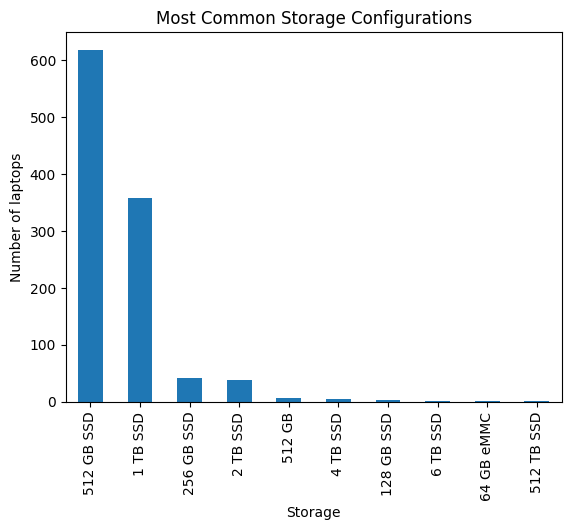

In [116]:
df["storage"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Storage")
plt.ylabel("Number of laptops")
plt.title("Most Common Storage Configurations")
plt.show()

### Price by Storage

Most laptops in the dataset have 512 GB SSD or 1 TB SSD storage.

The average price generally increases with storage capacity. Laptops with 2 TB, 4 TB and 6 TB storage have substantially higher average prices.

The `512 TB SSD` value appears to be an anomalous value and should be investigated during data quality checks.